# Regresión lineal: Salario mínimo vs. Año

Se reajusta la columna `Periodo` para que vaya de **0 a 30** (restando 1988).
El año original se guarda en `Anio` y se usa solo para graficar.

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [85]:
df = pd.read_csv("Salarios_minimos.csv")

# Guardar el año original para graficar y reajustar Periodo a 0-30
df["Anio"] = df["Periodo"]
df["Periodo"] = df["Periodo"] - 1988

df.head()

,Periodo,Salario,Anio
0,0.25,8.00,1988.25
1,1.00,8.64,1989.00
2,1.50,9.16,1989.50
3,2.00,10.08,1990.00
4,2.84,11.90,1990.84


In [86]:
# Regresión lineal con sklearn
X = df[["Periodo"]]   # variable independiente (0 a 30)
y = df["Salario"]     # variable dependiente

modelo = LinearRegression()
modelo.fit(X, y)

print("Intercepto (b0):", modelo.intercept_)
print("Pendiente  (b1):", modelo.coef_[0])
print("R^2:", modelo.score(X, y))

Intercepto (b0): 3.715577808507632
Pendiente  (b1): 2.5283288478118395
R^2: 0.9844566663095193


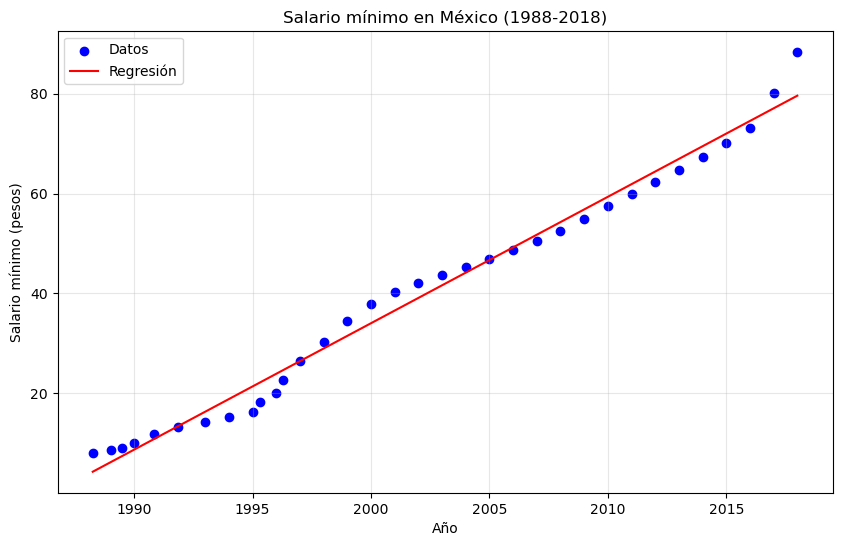

In [87]:
# Gráfica: se ajusta con Periodo (0-30) pero se muestran los años originales
df["Prediccion"] = modelo.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(df["Anio"], df["Salario"], color="blue", label="Datos")
plt.plot(df["Anio"], df["Prediccion"], color="red", label="Regresión")
plt.xlabel("Año")
plt.ylabel("Salario mínimo (pesos)")
plt.title("Salario mínimo en México (1988-2018)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [88]:
# Predicciones (se convierte el año a la escala 0-30 antes de predecir)
for anio in [1988, 2000, 2018, 2025]:
    X_nuevo = pd.DataFrame({"Periodo": [anio - 1988]})
    pred = modelo.predict(X_nuevo)[0]
    print(f"{anio}: {pred:.2f}")

1988: 3.72
2000: 34.06
2018: 79.57
2025: 97.26


---
# Regresión orden 9: Salario vs. Periodo (estandarizado)

Se ajusta un polinomio de **grado 9** de `Salario` en función de `Periodo`.
El `Periodo` se estandariza **manualmente** (sin `StandardScaler`) para que
tenga **media 0 y desviación estándar 1**: `(Periodo - media) / desviación`.
Las gráficas usan los años originales.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Estandarizar Periodo manualmente: media 0 y desviación estándar 1
media = df["Periodo"].mean()
desv = df["Periodo"].std()
df["Periodo_std"] = (df["Periodo"] - media) / desv

print("Media:", round(df["Periodo_std"].mean(), 6))
print("Desviación estándar:", round(df["Periodo_std"].std(), 6))

# Regresión polinomial de orden 9
X = df[["Periodo_std"]]
y = df["Salario"]

modelo9_sal = make_pipeline(PolynomialFeatures(9), LinearRegression())
modelo9_sal.fit(X, y)

print("R^2:", modelo9_sal.score(X, y))

In [ ]:
# Tabla de coeficientes de la regresión de orden 9
lin = modelo9_sal.named_steps["linearregression"]
coefs = lin.coef_.copy()
coefs[0] = lin.intercept_   # el término de grado 0 lo guarda el intercepto

tabla_coef_sal = pd.DataFrame({
    "Grado": range(10),
    "Coeficiente": coefs,
})
tabla_coef_sal

In [ ]:
# Gráfica: se ajusta con Periodo estandarizado, pero el eje x muestra los años originales
t_line = np.linspace(df["Periodo"].min(), df["Periodo"].max(), 300)
std_line = (t_line - media) / desv
anio_line = t_line + 1988
y_line = modelo9_sal.predict(pd.DataFrame({"Periodo_std": std_line}))

plt.figure(figsize=(10, 6))
plt.scatter(df["Anio"], df["Salario"], color="blue", label="Datos")
plt.plot(anio_line, y_line, color="red", label="Regresión orden 9")
plt.xlabel("Año")
plt.ylabel("Salario mínimo (pesos)")
plt.title("Salario mínimo vs. año (regresión polinomial orden 9)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
# Regresión polinomial (orden 9): duración vs. carga

Se ajusta un polinomio de **grado 9** de `duracion` en función de `carga`.
La carga se estandariza con **`StandardScaler`** para que tenga
**media 0 y desviación estándar 1**. Las gráficas usan la carga original.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

bat = pd.read_csv("bateria_tableta.txt")
bat.head()

In [ ]:
# Regresión polinomial de orden 9 con la carga estandarizada (StandardScaler)
X = bat[["carga"]]     # variable independiente
y = bat["duracion"]    # variable dependiente

modelo9 = make_pipeline(StandardScaler(), PolynomialFeatures(9), LinearRegression())
modelo9.fit(X, y)

sc = modelo9.named_steps["standardscaler"]
print("Media de la carga:", sc.mean_[0])
print("Desviación estándar:", sc.scale_[0])
print("R^2:", modelo9.score(X, y))

In [ ]:
# Gráfica: el modelo estandariza internamente, se predice con la carga original
c_line = np.linspace(bat["carga"].min(), bat["carga"].max(), 300)
y_line = modelo9.predict(pd.DataFrame({"carga": c_line}))

plt.figure(figsize=(10, 6))
plt.scatter(bat["carga"], bat["duracion"], color="blue", label="Datos")
plt.plot(c_line, y_line, color="red", label="Regresión orden 9 (StandardScaler)")
plt.xlabel("Carga")
plt.ylabel("Duración")
plt.title("Duración de la batería vs. carga (orden 9, StandardScaler)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()